In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [33]:
data_path = "../data"
processed_dir = os.path.join(data_path, "processed")
augmented_dir = os.path.join(data_path, "augmented")


In [34]:
splits = [
	("train", augmented_dir), 
	("dev", processed_dir), 
	("test", processed_dir)
]

dfs = []
for split, dir in splits:
	path = os.path.join(dir, f"stsb-es-{split}.csv",)
	df = pd.read_csv(path)
	dfs.append(df)

df = pd.concat(dfs, ignore_index=True)


In [35]:
df.columns


Index(['sentence1', 'sentence2', 'score', 'split', 'score_norm'], dtype='str')

In [36]:
df["split"].unique()


<StringArray>
['train', 'dev', 'test']
Length: 3, dtype: str

In [37]:
df.describe()


,score,score_norm
count,18121.000000,18121.000000
mean,2.668407,0.533681
std,1.474640,0.294928
min,0.000000,0.000000
25%,1.400000,0.280000
50%,3.000000,0.600000
75%,3.800000,0.760000
max,5.000000,1.000000


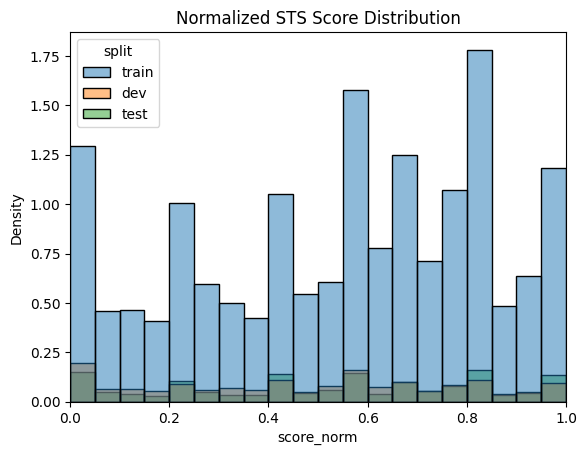

In [38]:
sns.histplot(df, x="score_norm", hue="split", bins=20, stat="density")
plt.title("Normalized STS Score Distribution")
plt.xlim(0,1)
plt.show()


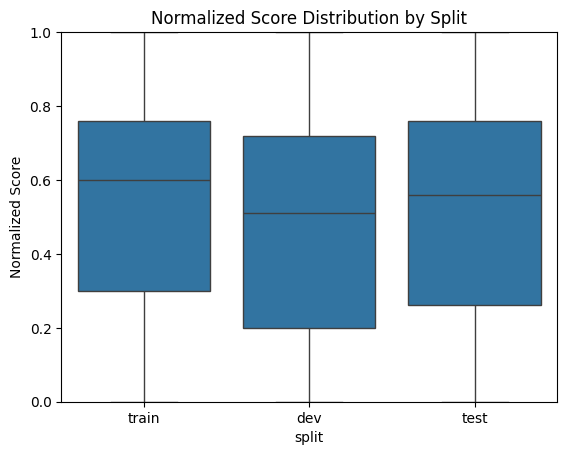

In [39]:
sns.boxplot(data=df, x="split", y="score_norm")

plt.title("Normalized Score Distribution by Split")
plt.ylabel("Normalized Score")
plt.ylim(0, 1)
plt.show()

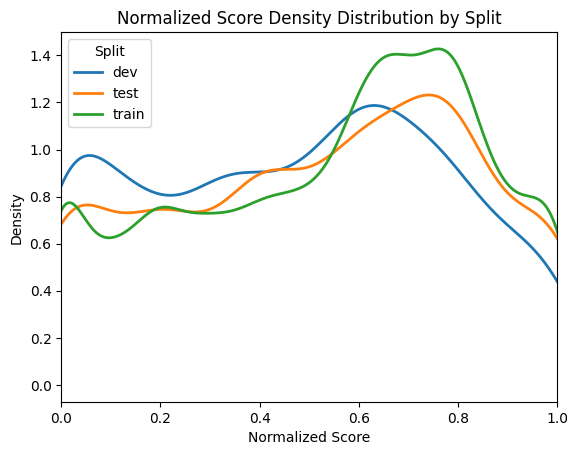

In [40]:
for split, data in df.groupby("split"):
	data["score_norm"].plot(kind="kde", label=split, linewidth=2)

plt.xlabel("Normalized Score")
plt.ylabel("Density")
plt.title("Normalized Score Density Distribution by Split")
plt.xlim(0, 1)
plt.legend(title="Split")
plt.show()

In [41]:
df["len1"] = df["sentence1"].str.split().str.len()
df["len2"] = df["sentence2"].str.split().str.len()

In [42]:
df[["len1", "len2"]].describe()

,len1,len2
count,18121.000000,18121.000000
mean,12.598311,12.545334
std,6.903294,6.752315
min,2.000000,2.000000
25%,8.000000,8.000000
50%,11.000000,11.000000
75%,15.000000,15.000000
max,80.000000,59.000000


In [43]:
PERCENTILE = 95

lengths = pd.concat([df["len1"], df["len2"]])
max_len = int(np.percentile(lengths, PERCENTILE))

print(max_len)

27


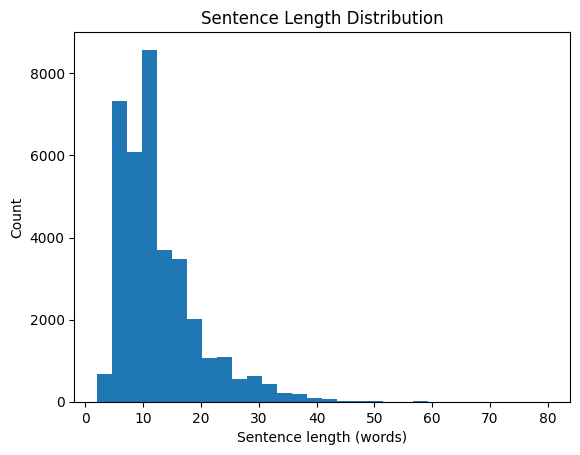

In [44]:
lengths = pd.concat([df["len1"], df["len2"]])

plt.hist(lengths, bins=30)
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()

In [48]:
max_len = 26

truncated = (df["len1"] > max_len).sum() + (df["len2"] > max_len).sum()
total = len(df) * 2

# Una buena práctica es truncar menos del 5% de las oraciones
print("Truncation rate:", truncated / total)

Truncation rate: 0.053032393355775066
